# 🧬 Aplicación de la Inteligencia Artificial en las Ciencias Biomédicas
## Sesión 02 — De los datos clínicos al apoyo diagnóstico

---

> **Curso:** Análisis de Datos con IA  
> **Nivel:** Principiante — Intermedio  
> **Duración estimada:** 3 horas  
> **Requisitos previos:** Sesión 01 (fundamentos de Python, Pandas, Scikit-learn)

---

### ¿Qué aprenderás hoy?

Al finalizar esta sesión serás capaz de:

1. Comprender el impacto real de la IA en diagnóstico, genómica, imágenes médicas y epidemiología.
2. Trabajar con datasets biomédicos reales: diabetes, cáncer de mama y datos epidemiológicos.
3. Aplicar modelos de clasificación para apoyar diagnósticos clínicos.
4. Interpretar métricas de evaluación críticas en contextos médicos (sensibilidad, especificidad, ROC-AUC).
5. Entender las implicaciones éticas del uso de IA en salud.
6. Construir una curva ROC y una matriz de confusión como herramientas de evaluación clínica.

---

### 🗺️ Mapa de la sesión

| # | Tema | Tipo |
|---|------|------|
| 1 | Panorama: IA en las Ciencias Biomédicas | Teoría |
| 2 | Métricas críticas en contexto médico | Teoría + Código |
| 3 | Caso 1 — Predicción de diabetes (Pima Indians) | Práctica |
| 4 | Caso 2 — Clasificación de tumores (cáncer de mama) | Práctica |
| 5 | Caso 3 — Análisis epidemiológico básico | Práctica |
| 6 | Visualizaciones clínicas: ROC, Matriz de Confusión | Práctica |
| 7 | Ética de la IA en salud | Teoría |
| 8 | Reflexión y próximos pasos | Teoría |

---
## 1. Panorama: IA en las Ciencias Biomédicas

### 1.1 ¿Por qué la medicina necesita IA?

La medicina moderna enfrenta desafíos de escala sin precedentes:

- Un radiólogo puede revisar hasta **100 imágenes** por turno; los algoritmos procesan **miles en minutos**.
- El genoma humano contiene **~3.000 millones** de pares de bases — imposible de analizar manualmente en busca de variantes.
- En una pandemia, los modelos de IA pueden simular la propagación viral y evaluar intervenciones en tiempo real.
- Los registros electrónicos de salud acumulan **petabytes** de datos que permanecen sin explotar.

La IA no reemplaza al médico: **amplifica su capacidad** de percibir patrones ocultos y tomar decisiones informadas.

### 1.2 Áreas de aplicación actual

```
┌─────────────────────────────────────────────────────────────────┐
│                   IA EN CIENCIAS BIOMÉDICAS                     │
├────────────────┬────────────────┬──────────────┬────────────────┤
│ 🔬 DIAGNÓSTICO │ 🧬 GENÓMICA   │ 🏥 CLÍNICA   │ 🌍 SALUD PÚB. │
│                │                │              │                │
│ • Imágenes     │ • Predicción   │ • Triaje     │ • Vigilancia   │
│   médicas      │   de variantes │   automático │   epidemiol.   │
│ • Patología    │ • Diseño de    │ • Predicción │ • Modelos de   │
│   digital      │   fármacos     │   reingresos │   propagación  │
│ • Detección    │ • Medicina     │ • Riesgo     │ • Detección de │
│   temprana     │   personaliz.  │   quirúrgico │   brotes       │
└────────────────┴────────────────┴──────────────┴────────────────┘
```

### 1.3 Casos de éxito documentados

| Aplicación | Sistema / Estudio | Resultado destacado |
|------------|-------------------|---------------------|
| Detección de retinopatía diabética | Google DeepMind (2016) | Sensibilidad ≥ 90%, comparable a oftalmólogo |
| Diagnóstico de cáncer de piel | Stanford (2017) | Precisión equivalente a dermatólogos certificados |
| Predicción de sepsis | Epic Sepsis Model | Alerta hasta 6 horas antes del evento |
| Plegamiento de proteínas | AlphaFold 2 (DeepMind, 2020) | Resolvió un problema de 50 años en biología |
| COVID-19: predicción de gravedad | Múltiples estudios 2020-2021 | Estratificación de riesgo en urgencias |

---

### 📚 Lecturas sugeridas — Sección 1

| Recurso | Tipo | Nivel | Enlace |
|---------|------|-------|--------|
| *"High-performance medicine: the convergence of human and artificial intelligence"* — Topol EJ, Nature Medicine (2019) | Artículo científico | Básico | https://doi.org/10.1038/s41591-018-0300-7 |
| *Deep Medicine* — Eric Topol | Libro | Básico | Basic Books, 2019 |
| *"Dermatologist-level classification of skin cancer with DNNs"* — Esteva et al., Nature (2017) | Paper seminal | Intermedio | https://doi.org/10.1038/nature21056 |
| *"AlphaFold: a solution to a 50-year-old grand challenge"* — DeepMind Blog | Artículo | Básico | https://deepmind.google/research/case-studies/alphafold |
| *The AI Revolution in Medicine* — Lee & Mazmanian | Libro | Básico-Intermedio | Pearson, 2023 |

---
## 2. Métricas críticas en el contexto médico

### 2.1 ¿Por qué la «exactitud» sola no es suficiente?

Imagina una enfermedad que afecta al **1%** de la población. Un modelo que **siempre predice «sano»** tendrá una exactitud del 99%, ¡pero no detectará ni un solo enfermo! En medicina, los errores tienen consecuencias graves:

| Error | Nombre técnico | Consecuencia |
|-------|---------------|-------------|
| Decir que un enfermo está sano | **Falso Negativo (FN)** | Paciente no recibe tratamiento ⚠️ |
| Decir que un sano está enfermo | **Falso Positivo (FP)** | Pruebas innecesarias, ansiedad, costo |

### 2.2 La Matriz de Confusión: el mapa completo del rendimiento

```
                    PREDICCIÓN DEL MODELO
                  ┌─────────────┬─────────────┐
                  │  Positivo   │  Negativo   │
                  │ (Enfermo)   │  (Sano)     │
┌─────────────────┼─────────────┼─────────────┤
│ REALIDAD        │             │             │
│ Positivo        │  TP         │  FN         │
│ (Realmente      │ (Verdadero  │ (Falso      │  ← No detectado ⚠️
│  Enfermo)       │  Positivo)  │  Negativo)  │
├─────────────────┼─────────────┼─────────────┤
│ Negativo        │  FP         │  TN         │
│ (Realmente Sano)│ (Falso      │ (Verdadero  │
│                 │  Positivo)  │  Negativo)  │
└─────────────────┴─────────────┴─────────────┘
```

### 2.3 Las métricas clave

| Métrica | Fórmula | Significado médico |
|---------|---------|--------------------|
| **Sensibilidad** (Recall) | TP / (TP + FN) | ¿Qué % de enfermos detecta? |
| **Especificidad** | TN / (TN + FP) | ¿Qué % de sanos descarta? |
| **Precisión** (VPP) | TP / (TP + FP) | De los que dice «enfermo», ¿cuántos lo son? |
| **F1-Score** | 2 × (Prec × Rec) / (Prec + Rec) | Balance entre precisión y sensibilidad |
| **ROC-AUC** | Área bajo la curva ROC | Capacidad discriminatoria global |

> 💡 **Regla práctica:** En tamizaje (screening), prioriza **alta sensibilidad** para no perder casos. En confirmación diagnóstica, prioriza **alta especificidad** para no sobre-diagnosticar.

---

### 📚 Lecturas sugeridas — Sección 2

| Recurso | Tipo | Nivel | Enlace |
|---------|------|-------|--------|
| *"Sensitivity, Specificity, and the Biometric ROC Curve"* — Flach (2004) | Paper | Intermedio | Google Scholar |
| *"Confusion Matrix — a practical guide"* — Towards Data Science | Artículo | Básico | https://towardsdatascience.com |
| *"An Introduction to ROC Analysis"* — Fawcett, Pattern Recognition Letters (2006) | Paper clásico | Intermedio | https://doi.org/10.1016/j.patrec.2005.10.010 |
| *Biostatistics for the Biological and Health Sciences* — Triola & Triola | Libro | Básico | Pearson |

In [1]:
# ============================================================
#  CELDA 0 — Instalación y configuración del entorno
#  Ejecuta esta celda PRIMERO antes de cualquier otra.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer

# Estilo visual
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11
PALETTE = ['#2EC4B6', '#E71D36', '#FF9F1C', '#011627', '#FDFFFC']
COLOR_POS = '#E71D36'   # Positivo / Enfermo
COLOR_NEG = '#2EC4B6'   # Negativo / Sano
COLOR_ACC = '#FF9F1C'   # Acento

print('✅ Entorno configurado correctamente.')
print('\n📦 Bibliotecas cargadas:')
print(f'   NumPy {np.__version__} | Pandas {pd.__version__}')
print('\n🎯 Sesión 02: IA en Ciencias Biomédicas — ¡Comenzamos!')

✅ Entorno configurado correctamente.

📦 Bibliotecas cargadas:
   NumPy 2.1.3 | Pandas 2.2.3

🎯 Sesión 02: IA en Ciencias Biomédicas — ¡Comenzamos!


---
## 3. Caso 1 — Predicción de Diabetes (Dataset Pima Indians)

### 3.1 Contexto clínico

La **diabetes mellitus tipo 2** es una de las enfermedades crónicas más prevalentes del mundo, con más de 500 millones de afectados (OMS, 2022). La detección temprana es crucial: los pacientes pueden ser asintomáticos durante años mientras el daño orgánico progresa silenciosamente.

### 3.2 El dataset Pima Indians Diabetes

Este dataset histórico del **Instituto Nacional de Diabetes de EE.UU.** contiene registros de mujeres de la comunidad Pima (Arizona), una de las poblaciones con mayor prevalencia de diabetes tipo 2 en el mundo. Es un benchmark clásico en bioinformática.

| Variable | Tipo | Descripción clínica |
|----------|------|---------------------|
| `Pregnancies` | Int | Número de embarazos |
| `Glucose` | Int | Glucosa plasmática en ayunas (mg/dL) |
| `BloodPressure` | Int | Presión arterial diastólica (mmHg) |
| `SkinThickness` | Int | Grosor del pliegue cutáneo tricipital (mm) |
| `Insulin` | Int | Insulina sérica 2h post-carga (μU/mL) |
| `BMI` | Float | Índice de Masa Corporal (kg/m²) |
| `DiabetesPedigreeFunction` | Float | Función de herencia familiar de diabetes |
| `Age` | Int | Edad (años) |
| `Outcome` | Int | **Diagnóstico** (0 = No diabética, 1 = Diabética) |

### 3.3 Objetivo

Construir un modelo de IA que, dado el perfil clínico de una paciente, **prediga si tiene o no diabetes**, evaluando especialmente la sensibilidad (no perder casos positivos).

---

### 📚 Lecturas sugeridas — Sección 3

| Recurso | Tipo | Nivel | Enlace |
|---------|------|-------|--------|
| *"Pima Indians Diabetes Database"* — UCI ML Repository | Dataset + Descripción | Básico | https://archive.ics.uci.edu/dataset/34/diabetes |
| *"Using Machine Learning to Predict Diabetes"* — Kavakiotis et al. (2017) | Review científico | Intermedio | https://doi.org/10.1016/j.compbiomed.2016.12.005 |
| *"IDF Diabetes Atlas — 10th Edition"* | Informe OMS | Básico | https://diabetesatlas.org |
| *"Predicting Diabetes with Machine Learning"* — Towards Data Science | Tutorial | Básico | https://towardsdatascience.com |

In [2]:
# ============================================================
#  CELDA 3.1 — Cargar y explorar el dataset de Diabetes
# ============================================================

url_diabetes = ('https://raw.githubusercontent.com/jbrownlee/Datasets/'
                'master/pima-indians-diabetes.data.csv')

columnas = ['Embarazos', 'Glucosa', 'PresionArterial', 'GrosorPiel',
            'Insulina', 'IMC', 'FuncionPedigree', 'Edad', 'Diagnostico']

diabetes = pd.read_csv(url_diabetes, names=columnas)

print(f'📊 Dataset cargado: {diabetes.shape[0]} pacientes × {diabetes.shape[1]} variables')
print(f'\n🏥 Distribución del diagnóstico:')
conteo = diabetes['Diagnostico'].value_counts()
for etiqueta, cantidad in conteo.items():
    nombre = 'Diabética  ' if etiqueta == 1 else 'No diabética'
    barra = '█' * (cantidad // 5)
    print(f'  {nombre}: {barra} {cantidad} ({cantidad/len(diabetes):.1%})')

print('\n📋 Primeros registros:')
diabetes.head()

📊 Dataset cargado: 768 pacientes × 9 variables

🏥 Distribución del diagnóstico:
  No diabética: ████████████████████████████████████████████████████████████████████████████████████████████████████ 500 (65.1%)
  Diabética  : █████████████████████████████████████████████████████ 268 (34.9%)

📋 Primeros registros:


,Embarazos,Glucosa,PresionArterial,GrosorPiel,Insulina,IMC,FuncionPedigree,Edad,Diagnostico
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# ============================================================
#  CELDA 3.2 — Análisis exploratorio clínico
# ============================================================

print('📈 Estadísticas por grupo diagnóstico:')
print()
diabetes.groupby('Diagnostico')[['Glucosa', 'IMC', 'Edad', 'PresionArterial']].mean().round(2)

📈 Estadísticas por grupo diagnóstico:



,Glucosa,IMC,Edad,PresionArterial
Diagnostico,,,,
0,109.98,30.30,31.19,68.18
1,141.26,35.14,37.07,70.82


In [4]:
# ============================================================
#  CELDA 3.3 — Detección y tratamiento de valores imposibles
#
#  En datos médicos, un valor de 0 en Glucosa o IMC
#  es clínicamente imposible — son valores faltantes
#  codificados como cero.
# ============================================================

vars_con_ceros = ['Glucosa', 'PresionArterial', 'GrosorPiel', 'Insulina', 'IMC']

print('⚠️  Valores cero (clínicamente imposibles) por variable:')
print()
for var in vars_con_ceros:
    ceros = (diabetes[var] == 0).sum()
    pct   = ceros / len(diabetes) * 100
    print(f'  {var:<20} {ceros:>4} registros ({pct:5.1f}%)')

# Reemplazamos ceros por NaN y luego imputamos con la mediana del grupo
diabetes_limpio = diabetes.copy()

for var in vars_con_ceros:
    diabetes_limpio[var] = diabetes_limpio[var].replace(0, np.nan)

# Imputar con mediana por grupo diagnóstico (más representativo)
for var in vars_con_ceros:
    for diag in [0, 1]:
        mediana = diabetes_limpio.loc[diabetes_limpio['Diagnostico'] == diag, var].median()
        mask = (diabetes_limpio['Diagnostico'] == diag) & (diabetes_limpio[var].isna())
        diabetes_limpio.loc[mask, var] = mediana

print(f'\n✅ Imputación completada.')
print(f'   Valores faltantes restantes: {diabetes_limpio.isnull().sum().sum()}')

⚠️  Valores cero (clínicamente imposibles) por variable:

  Glucosa                 5 registros (  0.7%)
  PresionArterial        35 registros (  4.6%)
  GrosorPiel            227 registros ( 29.6%)
  Insulina              374 registros ( 48.7%)
  IMC                    11 registros (  1.4%)

✅ Imputación completada.
   Valores faltantes restantes: 0


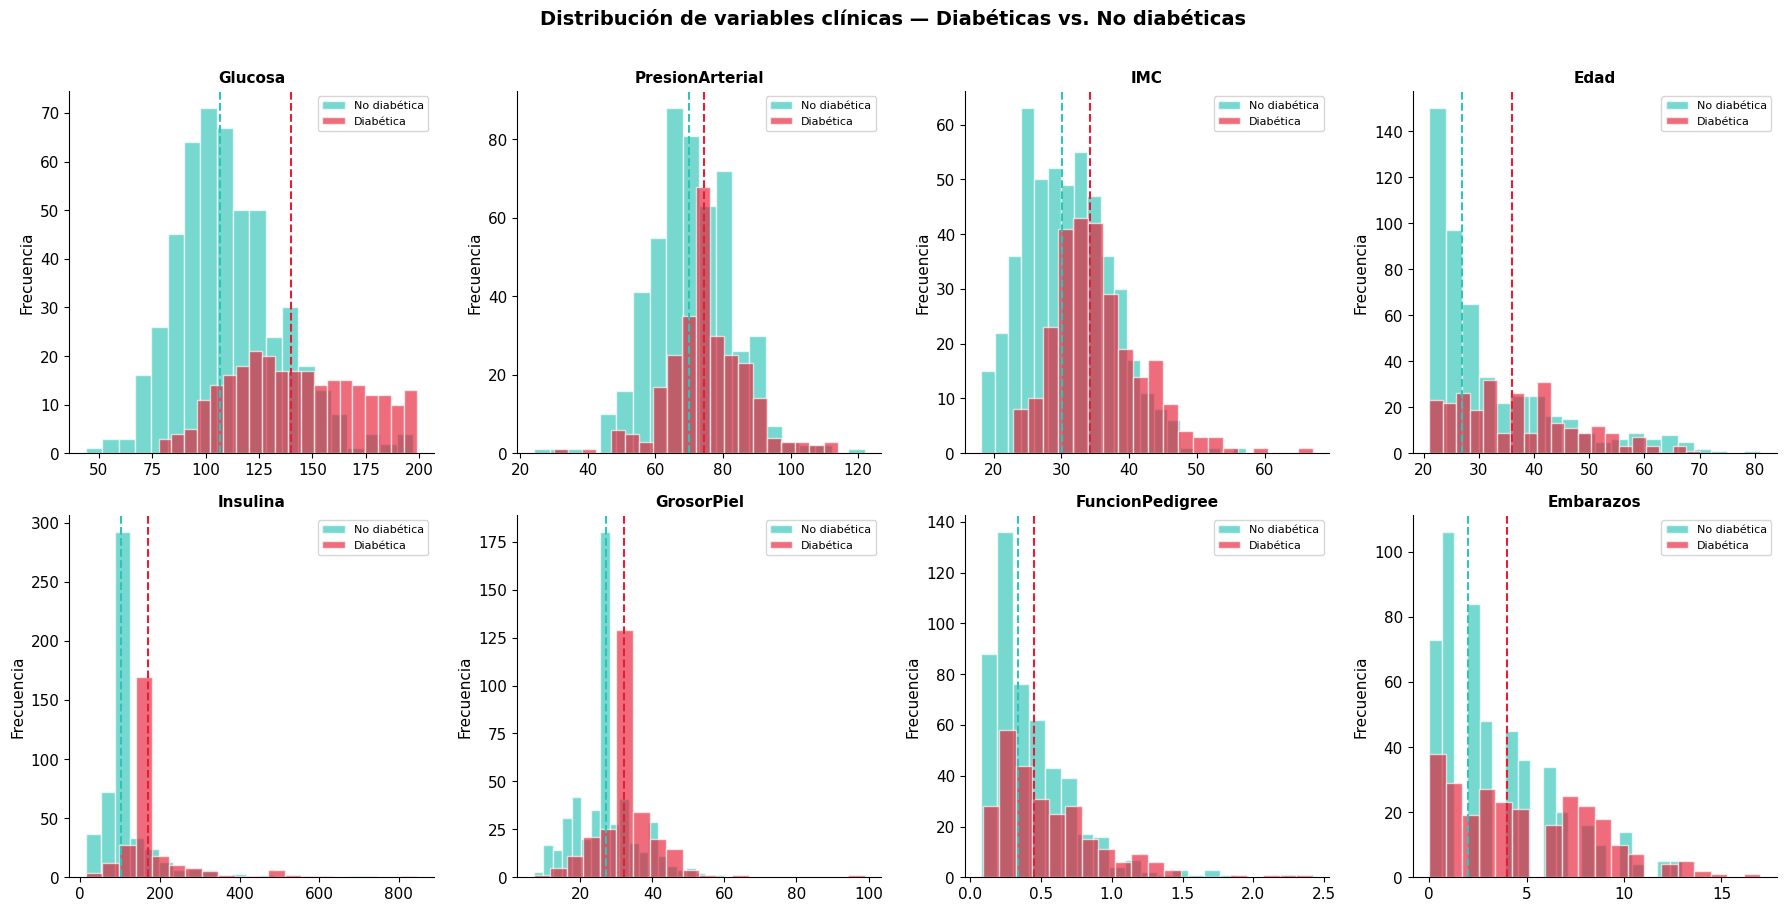

💡 Las líneas punteadas marcan la mediana de cada grupo.
   Glucosa e IMC muestran las diferencias más claras entre grupos.


In [5]:
# ============================================================
#  CELDA 3.4 — Visualización clínica: distribuciones
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Distribución de variables clínicas — Diabéticas vs. No diabéticas',
             fontsize=14, fontweight='bold', y=1.01)

variables = ['Glucosa', 'PresionArterial', 'IMC', 'Edad',
             'Insulina', 'GrosorPiel', 'FuncionPedigree', 'Embarazos']

for ax, var in zip(axes.flatten(), variables):
    for diag, color, label in [(0, COLOR_NEG, 'No diabética'), (1, COLOR_POS, 'Diabética')]:
        datos = diabetes_limpio[diabetes_limpio['Diagnostico'] == diag][var]
        ax.hist(datos, bins=20, alpha=0.65, color=color, label=label, edgecolor='white')
        ax.axvline(datos.median(), color=color, linestyle='--', linewidth=1.5)
    ax.set_title(var, fontsize=11, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('💡 Las líneas punteadas marcan la mediana de cada grupo.')
print('   Glucosa e IMC muestran las diferencias más claras entre grupos.')

In [6]:
# ============================================================
#  CELDA 3.5 — Entrenamiento y comparación de modelos
#
#  Compararemos 4 algoritmos de clasificación.
#  Usamos validación cruzada estratificada (5-fold)
#  para una evaluación más robusta.
# ============================================================

X = diabetes_limpio.drop('Diagnostico', axis=1)
y = diabetes_limpio['Diagnostico']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Definimos los modelos a comparar
modelos = {
    'Regresión Logística'  : Pipeline([('sc', StandardScaler()),
                                        ('m', LogisticRegression(random_state=42, max_iter=1000))]),
    'Árbol de Decisión'    : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('🏋️  Entrenando y evaluando modelos con validación cruzada 5-fold...')
print(f'   Datos de entrenamiento: {len(X_train)} | Datos de prueba: {len(X_test)}')
print()

resultados = {}
for nombre, modelo in modelos.items():
    scores_auc = cross_val_score(modelo, X_train, y_train, cv=cv,
                                  scoring='roc_auc', n_jobs=-1)
    scores_f1  = cross_val_score(modelo, X_train, y_train, cv=cv,
                                  scoring='f1', n_jobs=-1)
    resultados[nombre] = {
        'AUC_media': scores_auc.mean(),
        'AUC_std'  : scores_auc.std(),
        'F1_media' : scores_f1.mean()
    }
    print(f'  ✅ {nombre:<25}  ROC-AUC: {scores_auc.mean():.3f} ± {scores_auc.std():.3f}   F1: {scores_f1.mean():.3f}')

mejor_nombre = max(resultados, key=lambda k: resultados[k]['AUC_media'])
print(f'\n🏆 Mejor modelo: {mejor_nombre} (AUC = {resultados[mejor_nombre]["AUC_media"]:.3f})')

🏋️  Entrenando y evaluando modelos con validación cruzada 5-fold...
   Datos de entrenamiento: 614 | Datos de prueba: 154

  ✅ Regresión Logística        ROC-AUC: 0.872 ± 0.017   F1: 0.668
  ✅ Árbol de Decisión          ROC-AUC: 0.865 ± 0.032   F1: 0.767
  ✅ Random Forest              ROC-AUC: 0.940 ± 0.010   F1: 0.842
  ✅ Gradient Boosting          ROC-AUC: 0.943 ± 0.012   F1: 0.828

🏆 Mejor modelo: Gradient Boosting (AUC = 0.943)


In [7]:
# ============================================================
#  CELDA 3.6 — Evaluación final del mejor modelo
# ============================================================

mejor_modelo = modelos[mejor_nombre]
mejor_modelo.fit(X_train, y_train)
y_pred_db = mejor_modelo.predict(X_test)
y_prob_db = mejor_modelo.predict_proba(X_test)[:, 1]

sens = recall_score(y_test, y_pred_db)
prec = precision_score(y_test, y_pred_db)
esp  = recall_score(y_test, y_pred_db, pos_label=0)
auc  = roc_auc_score(y_test, y_prob_db)
f1   = f1_score(y_test, y_pred_db)

print(f'📋 Evaluación clínica — {mejor_nombre}')
print('=' * 50)
print(f'  Sensibilidad (recall)  : {sens:.3f}  ← % enfermas detectadas')
print(f'  Especificidad          : {esp:.3f}  ← % sanas correctamente descartadas')
print(f'  Precisión (VPP)        : {prec:.3f}  ← De las que dice enferma, % correctas')
print(f'  F1-Score               : {f1:.3f}  ← Balance precisión-sensibilidad')
print(f'  ROC-AUC                : {auc:.3f}  ← Capacidad discriminatoria global')
print()
print('📊 Reporte detallado:')
print(classification_report(y_test, y_pred_db,
                             target_names=['No diabética', 'Diabética']))

📋 Evaluación clínica — Gradient Boosting
  Sensibilidad (recall)  : 0.833  ← % enfermas detectadas
  Especificidad          : 0.910  ← % sanas correctamente descartadas
  Precisión (VPP)        : 0.833  ← De las que dice enferma, % correctas
  F1-Score               : 0.833  ← Balance precisión-sensibilidad
  ROC-AUC                : 0.957  ← Capacidad discriminatoria global

📊 Reporte detallado:
              precision    recall  f1-score   support

No diabética       0.91      0.91      0.91       100
   Diabética       0.83      0.83      0.83        54

    accuracy                           0.88       154
   macro avg       0.87      0.87      0.87       154
weighted avg       0.88      0.88      0.88       154



---
## 4. Caso 2 — Clasificación de Tumores: Cáncer de Mama

### 4.1 Contexto clínico

El **cáncer de mama** es el cáncer más frecuente en mujeres a nivel mundial. La diferenciación entre tumores **benignos** (no cancerosos) y **malignos** (cancerosos) mediante biopsia es un paso crítico en el diagnóstico. La IA puede analizar características morfológicas de las células para apoyar esta decisión.

### 4.2 El dataset Wisconsin Breast Cancer

Este dataset del **Hospital Universitario de Wisconsin** contiene mediciones computarizadas de características nucleares obtenidas por **Aspiración con Aguja Fina (AAF)** de masas mamarias. Cada característica se calcula como media, error estándar y «peor» valor (percentil 95).

**Variables principales (10 características × 3 estadísticos = 30 features):**

| Característica | Descripción biológica |
|----------------|----------------------|
| `radius` | Radio medio de los núcleos celulares |
| `texture` | Desviación estándar de intensidades en escala de grises |
| `perimeter` | Perímetro del núcleo |
| `area` | Área del núcleo |
| `smoothness` | Variación local en longitud de radio |
| `compactness` | Perímetro² / área - 1.0 |
| `concavity` | Severidad de porciones cóncavas del contorno |
| `concave points` | Número de porciones cóncavas del contorno |
| `symmetry` | Simetría del núcleo |
| `fractal dimension` | Aproximación de «coastline» — 1 |

**Variable objetivo:** M = Maligno | B = Benigno

---

### 📚 Lecturas sugeridas — Sección 4

| Recurso | Tipo | Nivel | Enlace |
|---------|------|-------|--------|
| *"Nuclear Feature Extraction for Breast Tumor Diagnosis"* — Street et al. (1993) | Paper original | Intermedio | IS&T/SPIE 1993 Proceedings |
| *"Breast Cancer Wisconsin Dataset"* — UCI Repository | Dataset | Básico | https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic |
| *"Machine Learning in Breast Cancer Diagnosis"* — Kourou et al., Comput. Struct. Biotechnol. J. (2015) | Review | Intermedio | https://doi.org/10.1016/j.csbj.2014.11.005 |
| *"AI in Oncology"* — Bhinder et al., Cancer Cell (2021) | Review | Avanzado | https://doi.org/10.1016/j.ccell.2021.01.010 |

In [8]:
# ============================================================
#  CELDA 4.1 — Cargar y explorar el dataset de Cáncer de Mama
# ============================================================

cancer_raw = load_breast_cancer()
cancer = pd.DataFrame(data=cancer_raw.data, columns=cancer_raw.feature_names)
cancer['diagnostico'] = cancer_raw.target  # 0=Maligno, 1=Benigno
cancer['diagnostico_txt'] = cancer['diagnostico'].map({0: 'Maligno', 1: 'Benigno'})

print(f'📊 Dataset: {cancer.shape[0]} biopsias × {cancer.shape[1]-2} características')
print()
conteo = cancer['diagnostico_txt'].value_counts()
for etiqueta, n in conteo.items():
    icono = '🔴' if etiqueta == 'Maligno' else '🟢'
    barra = '█' * (n // 5)
    print(f'  {icono} {etiqueta:<10}: {barra} {n} ({n/len(cancer):.1%})')

print()
print('🔬 Primeras 5 biopsias (columnas resumidas):')
cancer[['mean radius', 'mean texture', 'mean area',
        'mean concavity', 'diagnostico_txt']].head()

📊 Dataset: 569 biopsias × 30 características

  🟢 Benigno   : ███████████████████████████████████████████████████████████████████████ 357 (62.7%)
  🔴 Maligno   : ██████████████████████████████████████████ 212 (37.3%)

🔬 Primeras 5 biopsias (columnas resumidas):


,mean radius,mean texture,mean area,mean concavity,diagnostico_txt
0,17.99,10.38,1001.0,0.3001,Maligno
1,20.57,17.77,1326.0,0.0869,Maligno
2,19.69,21.25,1203.0,0.1974,Maligno
3,11.42,20.38,386.1,0.2414,Maligno
4,20.29,14.34,1297.0,0.1980,Maligno


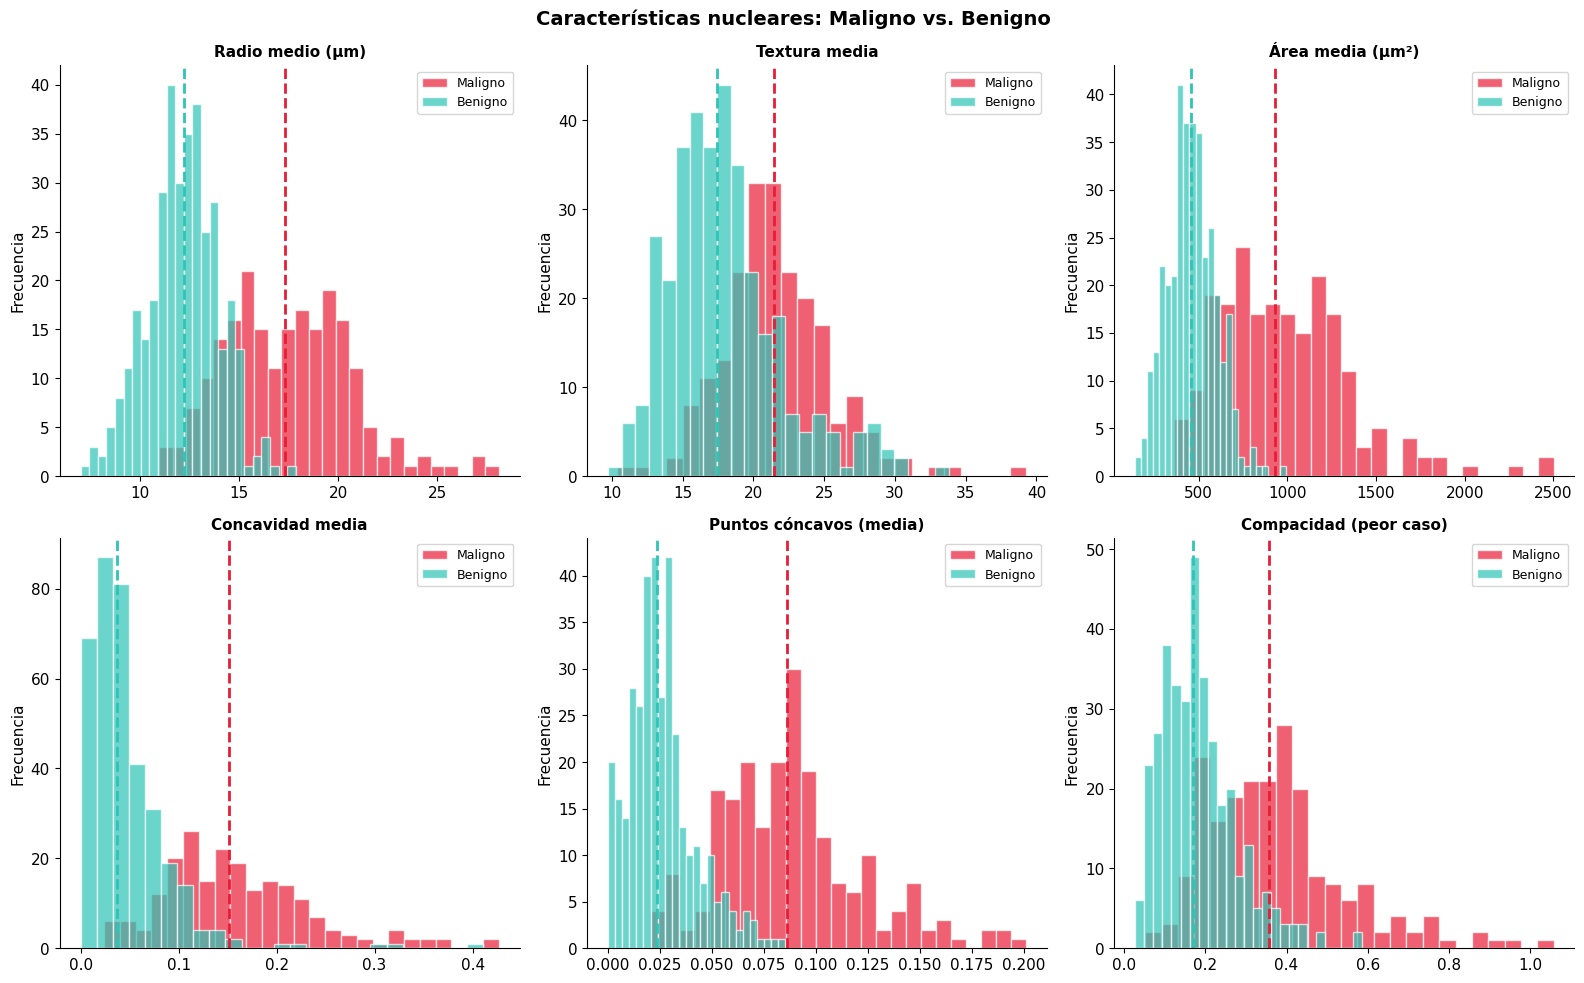

💡 Los tumores malignos tienden a tener núcleos más grandes,
   más irregulares (mayor concavidad) y menos simétricos.


In [9]:
# ============================================================
#  CELDA 4.2 — Visualización: características clave
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Características nucleares: Maligno vs. Benigno',
             fontsize=14, fontweight='bold')

features_clave = [
    ('mean radius',           'Radio medio (μm)'),
    ('mean texture',          'Textura media'),
    ('mean area',             'Área media (μm²)'),
    ('mean concavity',        'Concavidad media'),
    ('mean concave points',   'Puntos cóncavos (media)'),
    ('worst compactness',     'Compacidad (peor caso)')
]

for ax, (feat, titulo) in zip(axes.flatten(), features_clave):
    for diag, color, label in [('Maligno', COLOR_POS, 'Maligno'),
                                 ('Benigno', COLOR_NEG, 'Benigno')]:
        datos = cancer[cancer['diagnostico_txt'] == diag][feat]
        ax.hist(datos, bins=25, alpha=0.7, color=color, label=label, edgecolor='white')
        ax.axvline(datos.median(), color=color, linestyle='--', linewidth=2)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print('💡 Los tumores malignos tienden a tener núcleos más grandes,\n'
      '   más irregulares (mayor concavidad) y menos simétricos.')

In [10]:
# ============================================================
#  CELDA 4.3 — Modelo de clasificación con Random Forest
#
#  Random Forest es un conjunto (ensemble) de árboles
#  de decisión que votan colectivamente. Es robusto
#  y muy efectivo en datos biomédicos.
# ============================================================

X_c = cancer.drop(['diagnostico', 'diagnostico_txt'], axis=1)
y_c = cancer['diagnostico']

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
)

rf_cancer = Pipeline([
    ('sc', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=8,
                                   random_state=42, class_weight='balanced'))
])

rf_cancer.fit(X_c_train, y_c_train)
y_c_pred = rf_cancer.predict(X_c_test)
y_c_prob = rf_cancer.predict_proba(X_c_test)[:, 0]  # prob de Maligno

# Métricas (etiqueta positiva = 0 = Maligno, lo que queremos detectar)
sens_c = recall_score(y_c_test, y_c_pred, pos_label=0)
esp_c  = recall_score(y_c_test, y_c_pred, pos_label=1)
auc_c  = roc_auc_score(y_c_test, y_c_prob)
acc_c  = accuracy_score(y_c_test, y_c_pred)

print('🔬 RESULTADO: Clasificador de Tumores Mamarios (Random Forest)')
print('=' * 58)
print(f'  Exactitud              : {acc_c:.3f}')
print(f'  Sensibilidad (maligno) : {sens_c:.3f}  ← Tumores malignos detectados')
print(f'  Especificidad (benigno): {esp_c:.3f}  ← Tumores benignos correctamente clasificados')
print(f'  ROC-AUC                : {auc_c:.3f}')
print()
print(classification_report(y_c_test, y_c_pred,
                             target_names=['Maligno', 'Benigno']))

🔬 RESULTADO: Clasificador de Tumores Mamarios (Random Forest)
  Exactitud              : 0.947
  Sensibilidad (maligno) : 0.929  ← Tumores malignos detectados
  Especificidad (benigno): 0.958  ← Tumores benignos correctamente clasificados
  ROC-AUC                : 0.006

              precision    recall  f1-score   support

     Maligno       0.93      0.93      0.93        42
     Benigno       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



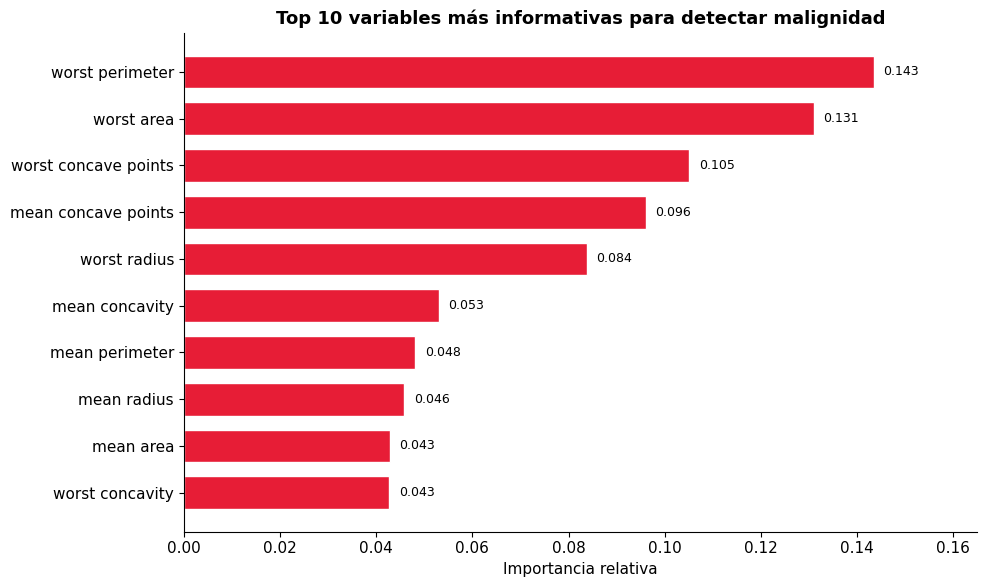

💡 Las características del "peor caso" (worst) y la concavidad
   son las más informativas — coincide con la literatura clínica.


In [11]:
# ============================================================
#  CELDA 4.4 — Top 10 características más importantes
# ============================================================

importancias_c = pd.Series(
    rf_cancer.named_steps['rf'].feature_importances_,
    index=X_c.columns
).sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importancias_c.index, importancias_c.values,
               color=COLOR_POS, edgecolor='white', height=0.7)

for bar, val in zip(bars, importancias_c.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Top 10 variables más informativas para detectar malignidad',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia relativa')
ax.set_xlim(0, importancias_c.max() * 1.15)
plt.tight_layout()
plt.show()

print('💡 Las características del "peor caso" (worst) y la concavidad')
print('   son las más informativas — coincide con la literatura clínica.')

---
## 5. Caso 3 — Análisis Epidemiológico Básico

### 5.1 Epidemiología y la IA

La **epidemiología** estudia la distribución y determinantes de las enfermedades en poblaciones. Con IA podemos:

- Identificar **factores de riesgo** en grandes cohortes poblacionales.
- Modelar la **propagación** de enfermedades infecciosas.
- Predecir **brotes** a partir de señales ambientales, climáticas y de movilidad.
- Detectar **clusters espaciales** de enfermedades.

### 5.2 Lo que haremos

Simularemos un estudio de cohorte sobre **enfermedades cardiovasculares** (ECV) basado en el famoso **Framingham Heart Study** — uno de los estudios epidemiológicos más importantes de la historia, en curso desde 1948.

> 📌 **Nota:** Utilizaremos datos sintéticos inspirados en el Framingham para fines educativos. Los patrones estadísticos reflejan los hallazgos reales publicados.

---

### 📚 Lecturas sugeridas — Sección 5

| Recurso | Tipo | Nivel | Enlace |
|---------|------|-------|--------|
| *"The Framingham Heart Study: 75 Years of Lessons Learned"* — NEJM (2023) | Artículo | Básico | https://www.nejm.org |
| *"Machine Learning in Epidemiology"* — Bi et al., Annals of Epidemiology (2019) | Review | Intermedio | https://doi.org/10.1016/j.annepidem.2018.11.005 |
| *Epidemiology: An Introduction* — Rothman | Libro | Básico | Oxford University Press |
| *"AI Applications in Epidemiology"* — Brownstein et al. | Review | Intermedio | The Lancet Digital Health |

In [12]:
# ============================================================
#  CELDA 5.1 — Generación de datos epidemiológicos sintéticos
#              basados en el Framingham Heart Study
# ============================================================

np.random.seed(2024)
N = 1500  # Tamaño de la cohorte

# Variables demográficas
edad       = np.random.randint(35, 75, N)
sexo       = np.random.choice([0, 1], N)        # 0=Mujer, 1=Hombre
fumador    = np.random.choice([0, 1], N, p=[0.70, 0.30])

# Variables clínicas (correlacionadas con edad y factores de riesgo)
colesterol = np.clip(180 + edad*0.8 + fumador*15 + np.random.normal(0, 25, N), 140, 320).astype(int)
pas        = np.clip(100 + edad*0.7 + sexo*5 + fumador*8 + np.random.normal(0, 15, N), 90, 200).astype(int)
glucosa    = np.clip(80 + edad*0.3 + np.random.normal(0, 15, N), 60, 250).astype(int)
imc        = np.clip(22 + np.random.normal(0, 4, N), 17, 45).round(1)

# Probabilidad de ECV (basada en factores de riesgo de Framingham)
prob_ecv = (
    -6.0
    + 0.04 * edad
    + 0.5  * sexo
    + 0.8  * fumador
    + 0.01 * colesterol
    + 0.02 * (pas - 120)
    + 0.15 * (imc - 25)
)
prob_ecv = 1 / (1 + np.exp(-prob_ecv))  # Función logística
ecv = (np.random.uniform(0, 1, N) < prob_ecv).astype(int)

# Crear DataFrame
framingham = pd.DataFrame({
    'edad': edad,
    'sexo': pd.Categorical(sexo).rename_categories({0: 'Mujer', 1: 'Hombre'}),
    'fumador': pd.Categorical(fumador).rename_categories({0: 'No', 1: 'Sí'}),
    'colesterol_mgdl': colesterol,
    'pas_mmhg': pas,
    'glucosa_mgdl': glucosa,
    'imc': imc,
    'evento_ecv': ecv
})

print(f'🫀 Cohorte simulada: {len(framingham)} participantes')
n_ecv = framingham['evento_ecv'].sum()
print(f'   Con evento cardiovascular: {n_ecv} ({n_ecv/N:.1%})')
print(f'   Sin evento cardiovascular: {N-n_ecv} ({(N-n_ecv)/N:.1%})')
print()
framingham.head()

🫀 Cohorte simulada: 1500 participantes
   Con evento cardiovascular: 453 (30.2%)
   Sin evento cardiovascular: 1047 (69.8%)



,edad,sexo,fumador,colesterol_mgdl,pas_mmhg,glucosa_mgdl,imc,evento_ecv
0,43,Mujer,No,194,118,63,20.8,0
1,67,Hombre,No,216,163,84,27.0,0
2,35,Hombre,No,247,139,107,17.0,0
3,62,Hombre,No,223,170,104,22.6,0
4,71,Hombre,No,245,146,115,20.5,0


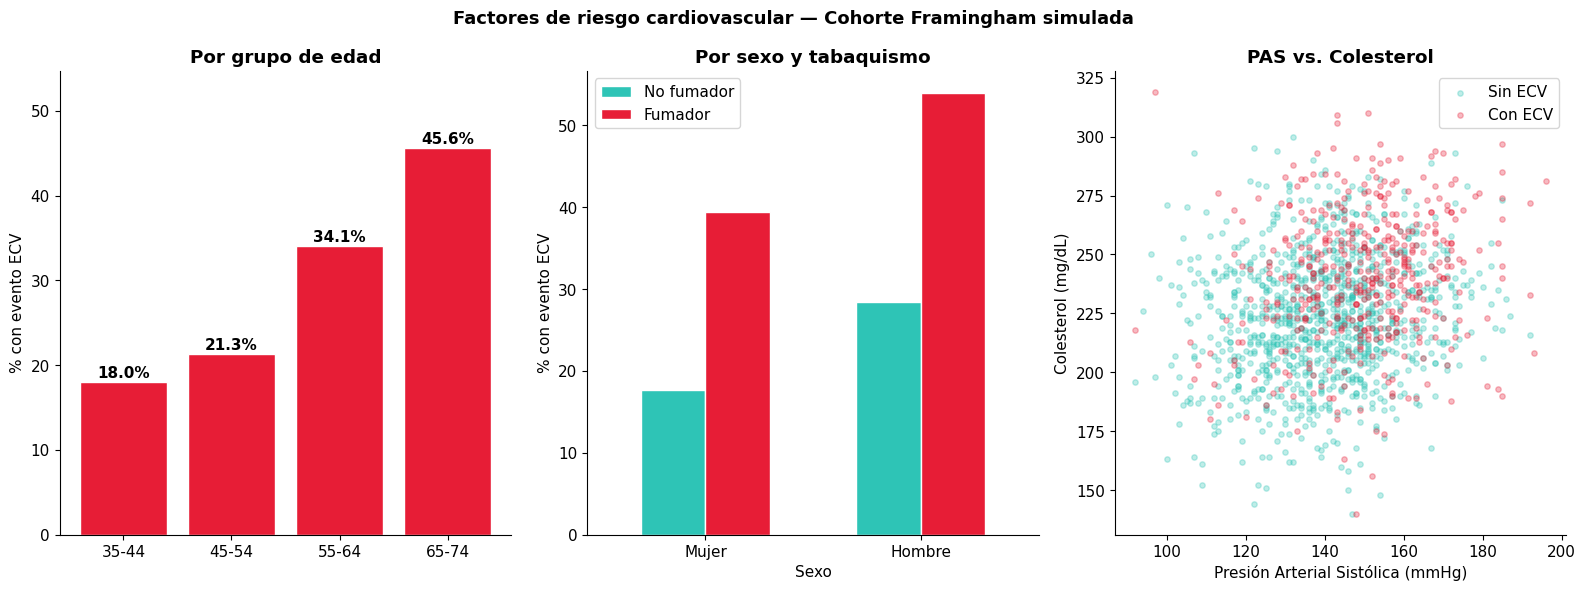

💡 El riesgo cardiovascular aumenta con la edad, el tabaquismo
   y la combinación de presión arterial alta + colesterol elevado.


In [13]:
# ============================================================
#  CELDA 5.2 — Análisis de factores de riesgo cardiovascular
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Factores de riesgo cardiovascular — Cohorte Framingham simulada',
             fontsize=13, fontweight='bold')

# 1. Tasa de ECV por grupo de edad
framingham['grupo_edad'] = pd.cut(framingham['edad'],
                                   bins=[34, 44, 54, 64, 75],
                                   labels=['35-44', '45-54', '55-64', '65-74'])
tasa_edad = framingham.groupby('grupo_edad')['evento_ecv'].mean() * 100
axes[0].bar(tasa_edad.index, tasa_edad.values, color=COLOR_POS, edgecolor='white')
for i, v in enumerate(tasa_edad.values):
    axes[0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Por grupo de edad', fontweight='bold')
axes[0].set_ylabel('% con evento ECV')
axes[0].set_ylim(0, tasa_edad.max() * 1.2)

# 2. Tasa de ECV por sexo y tabaquismo
tasa_sf = framingham.groupby(['sexo', 'fumador'])['evento_ecv'].mean().unstack() * 100
tasa_sf.plot(kind='bar', ax=axes[1], color=[COLOR_NEG, COLOR_POS],
             edgecolor='white', rot=0, width=0.6)
axes[1].set_title('Por sexo y tabaquismo', fontweight='bold')
axes[1].set_ylabel('% con evento ECV')
axes[1].legend(['No fumador', 'Fumador'])
axes[1].set_xlabel('Sexo')

# 3. Relación Presión Arterial vs. ECV
for ecv_val, color, label in [(0, COLOR_NEG, 'Sin ECV'), (1, COLOR_POS, 'Con ECV')]:
    datos = framingham[framingham['evento_ecv'] == ecv_val]
    axes[2].scatter(datos['pas_mmhg'], datos['colesterol_mgdl'],
                    alpha=0.3, c=color, label=label, s=15)
axes[2].set_title('PAS vs. Colesterol', fontweight='bold')
axes[2].set_xlabel('Presión Arterial Sistólica (mmHg)')
axes[2].set_ylabel('Colesterol (mg/dL)')
axes[2].legend()

plt.tight_layout()
plt.show()

print('💡 El riesgo cardiovascular aumenta con la edad, el tabaquismo')
print('   y la combinación de presión arterial alta + colesterol elevado.')

In [14]:
# ============================================================
#  CELDA 5.3 — Modelo de riesgo cardiovascular
#              (inspirado en el Score de Framingham)
# ============================================================

fram_modelo = framingham.copy()
fram_modelo['sexo_num']    = (fram_modelo['sexo'] == 'Hombre').astype(int)
fram_modelo['fumador_num'] = (fram_modelo['fumador'] == 'Sí').astype(int)

X_f = fram_modelo[['edad', 'sexo_num', 'fumador_num',
                    'colesterol_mgdl', 'pas_mmhg', 'glucosa_mgdl', 'imc']]
y_f = fram_modelo['evento_ecv']

X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(
    X_f, y_f, test_size=0.2, random_state=42, stratify=y_f
)

# Regresión Logística (el modelo estadístico detrás del Score de Framingham original)
modelo_ecv = Pipeline([
    ('sc', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])
modelo_ecv.fit(X_f_train, y_f_train)

y_f_pred = modelo_ecv.predict(X_f_test)
y_f_prob = modelo_ecv.predict_proba(X_f_test)[:, 1]

print('🫀 MODELO DE RIESGO CARDIOVASCULAR — Regresión Logística')
print('=' * 55)
print(f'  ROC-AUC      : {roc_auc_score(y_f_test, y_f_prob):.3f}')
print(f'  Sensibilidad : {recall_score(y_f_test, y_f_pred):.3f}')
print(f'  Especificidad: {recall_score(y_f_test, y_f_pred, pos_label=0):.3f}')
print()

# Coeficientes del modelo (interpretabilidad)
coefs = pd.Series(
    modelo_ecv.named_steps['lr'].coef_[0],
    index=X_f.columns
).sort_values(key=abs, ascending=False)

print('📊 Contribución de cada factor de riesgo (coeficientes):')
for var, coef in coefs.items():
    signo = '+' if coef >= 0 else ''
    barra = '█' * int(abs(coef) * 6)
    print(f'  {var:<22} {signo}{coef:.3f}  {barra}')

print()
print('💡 Coeficientes positivos aumentan el riesgo, negativos lo reducen.')

🫀 MODELO DE RIESGO CARDIOVASCULAR — Regresión Logística
  ROC-AUC      : 0.737
  Sensibilidad : 0.429
  Especificidad: 0.861

📊 Contribución de cada factor de riesgo (coeficientes):
  imc                    +0.577  ███
  colesterol_mgdl        +0.537  ███
  fumador_num            +0.430  ██
  edad                   +0.394  ██
  sexo_num               +0.378  ██
  pas_mmhg               +0.300  █
  glucosa_mgdl           +0.094  

💡 Coeficientes positivos aumentan el riesgo, negativos lo reducen.


---
## 6. Visualizaciones Clínicas: Curva ROC y Matriz de Confusión

### 6.1 La Curva ROC (Receiver Operating Characteristic)

La curva ROC es la **herramienta visual estándar** en medicina para evaluar la capacidad diagnóstica de una prueba o modelo.

- **Eje X:** Tasa de Falsos Positivos (1 - Especificidad)
- **Eje Y:** Sensibilidad (Tasa de Verdaderos Positivos)
- **Línea diagonal:** Modelo sin poder discriminatorio (equivale a tirar una moneda)
- **Área bajo la curva (AUC):** 0.5 = azar | 0.7–0.8 = bueno | 0.8–0.9 = muy bueno | >0.9 = excelente

### 6.2 ¿Cómo elegir el umbral de decisión?

Por defecto, los modelos usan **probabilidad > 0.5** como umbral. En medicina, a veces es preferible **bajar el umbral** (ej: 0.3) para aumentar la sensibilidad aunque se pierda especificidad — especialmente en enfermedades graves donde no queremos perder casos.

---

### 📚 Lecturas sugeridas — Sección 6

| Recurso | Tipo | Nivel | Enlace |
|---------|------|-------|--------|
| *"ROC Curves for Dummies"* — Towards Data Science | Artículo | Básico | https://towardsdatascience.com |
| *"The Relationship Between Precision-Recall and ROC Curves"* — Davis & Goadrich (2006) | Paper | Intermedio | ICML Proceedings |
| *"A primer on using the ROC curve in clinical research"* — Hajian-Tilaki, Caspian J Intern Med (2013) | Artículo | Básico-Intermedio | PubMed |
| *"Evaluating Machine Learning Models"* — Alice Zheng | Libro breve | Básico | O'Reilly (descarga gratuita) |

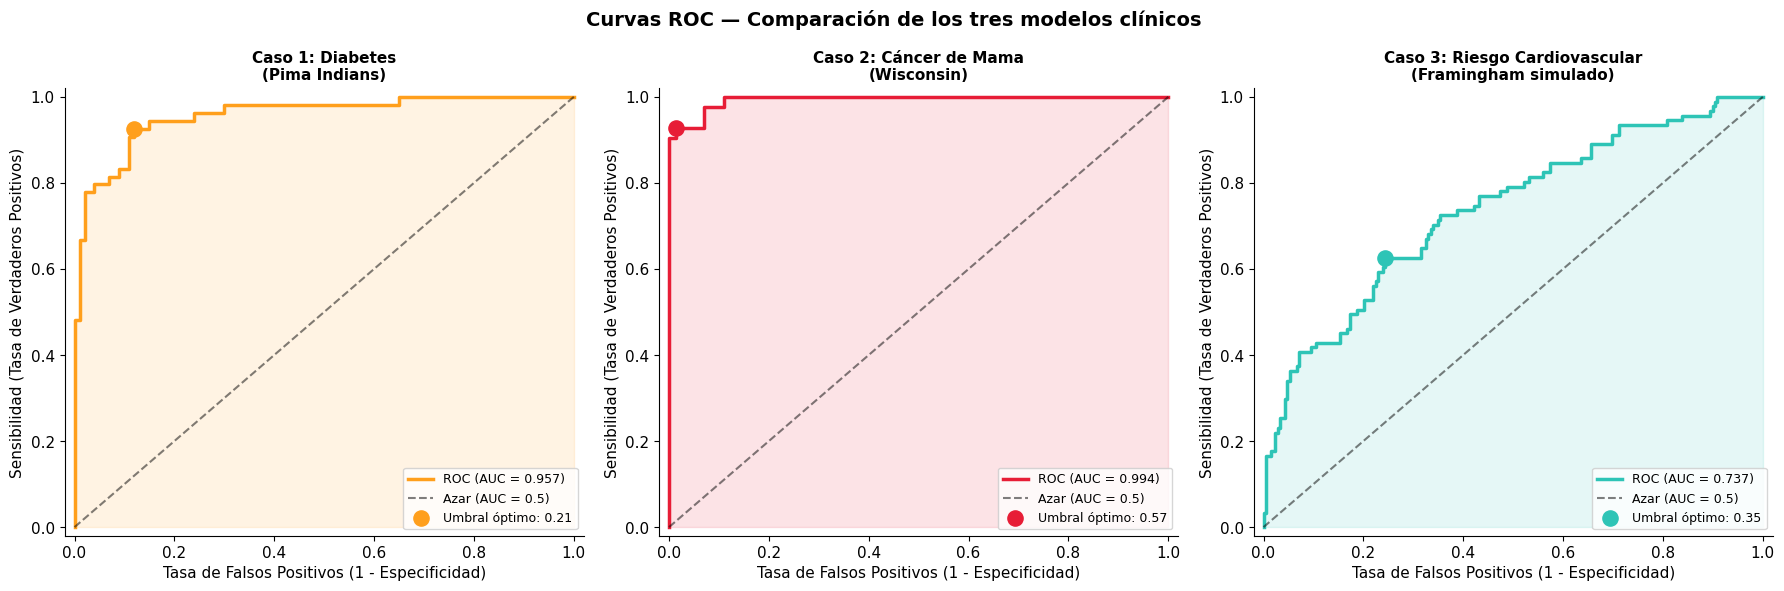

In [15]:
# ============================================================
#  CELDA 6.1 — Curvas ROC: los tres casos clínicos
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Curvas ROC — Comparación de los tres modelos clínicos',
             fontsize=14, fontweight='bold')

casos = [
    {
        'titulo'  : 'Caso 1: Diabetes\n(Pima Indians)',
        'y_test'  : y_test,
        'y_prob'  : mejor_modelo.predict_proba(X_test)[:, 1],
        'color'   : '#FF9F1C'
    },
    {
        'titulo'  : 'Caso 2: Cáncer de Mama\n(Wisconsin)',
        'y_test'  : 1 - y_c_test,  # invertimos para que 1=Maligno sea positivo
        'y_prob'  : rf_cancer.predict_proba(X_c_test)[:, 0],
        'color'   : COLOR_POS
    },
    {
        'titulo'  : 'Caso 3: Riesgo Cardiovascular\n(Framingham simulado)',
        'y_test'  : y_f_test,
        'y_prob'  : y_f_prob,
        'color'   : COLOR_NEG
    }
]

for ax, caso in zip(axes, casos):
    fpr, tpr, umbral = roc_curve(caso['y_test'], caso['y_prob'])
    auc_val = roc_auc_score(caso['y_test'], caso['y_prob'])

    ax.plot(fpr, tpr, color=caso['color'], lw=2.5,
            label=f'ROC (AUC = {auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Azar (AUC = 0.5)')

    # Punto óptimo (máxima distancia de la diagonal)
    idx_optimo = np.argmax(tpr - fpr)
    ax.scatter(fpr[idx_optimo], tpr[idx_optimo], s=120,
               color=caso['color'], zorder=5,
               label=f'Umbral óptimo: {umbral[idx_optimo]:.2f}')

    ax.fill_between(fpr, tpr, alpha=0.12, color=caso['color'])
    ax.set_title(caso['titulo'], fontsize=11, fontweight='bold')
    ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
    ax.set_ylabel('Sensibilidad (Tasa de Verdaderos Positivos)')
    ax.legend(fontsize=9, loc='lower right')
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.show()

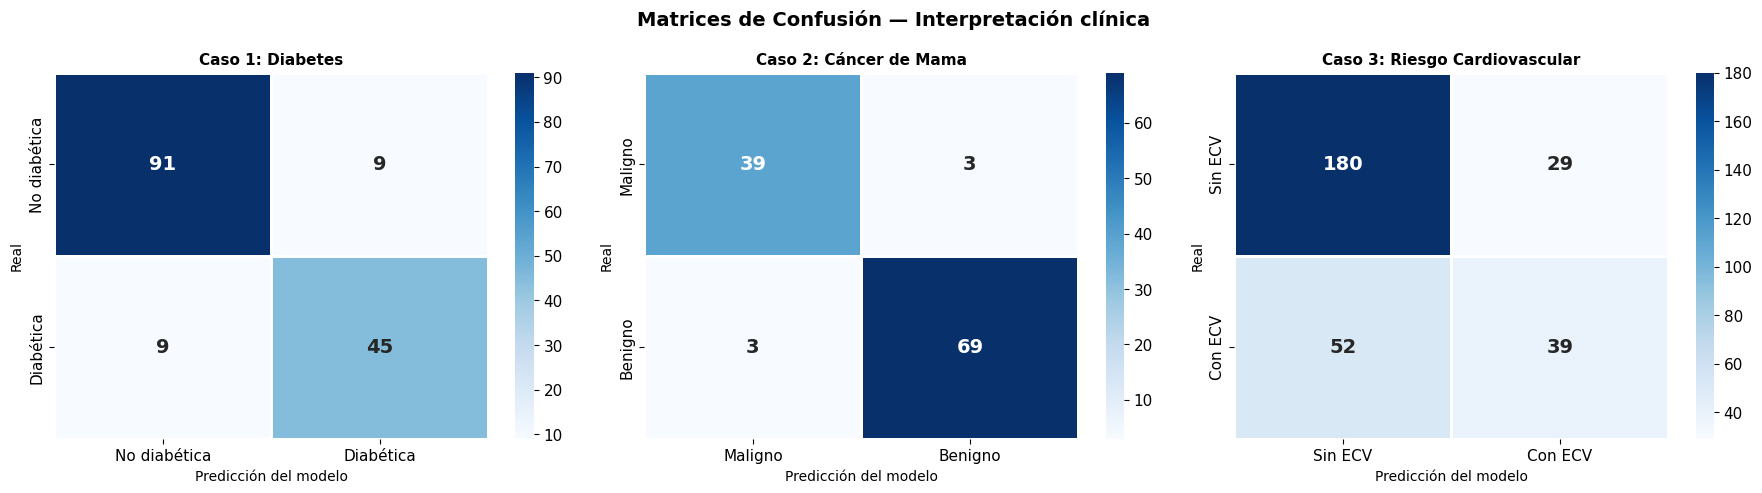

📋 Lectura de la matriz (ejemplo 2×2):
   ┌────────────┬────────────┐
   │ Verdadero  │ Falso      │  ← Fila 0: Clase Negativa Real
   │ Negativo   │ Positivo   │
   ├────────────┼────────────┤
   │ Falso      │ Verdadero  │  ← Fila 1: Clase Positiva Real
   │ Negativo   │ Positivo   │
   └────────────┴────────────┘


In [16]:
# ============================================================
#  CELDA 6.2 — Matrices de Confusión anotadas clínicamente
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de Confusión — Interpretación clínica',
             fontsize=14, fontweight='bold')

casos_cm = [
    {
        'titulo'  : 'Caso 1: Diabetes',
        'y_test'  : y_test,
        'y_pred'  : y_pred_db,
        'etiquetas': ['No diabética', 'Diabética']
    },
    {
        'titulo'  : 'Caso 2: Cáncer de Mama',
        'y_test'  : y_c_test,
        'y_pred'  : y_c_pred,
        'etiquetas': ['Maligno', 'Benigno']
    },
    {
        'titulo'  : 'Caso 3: Riesgo Cardiovascular',
        'y_test'  : y_f_test,
        'y_pred'  : y_f_pred,
        'etiquetas': ['Sin ECV', 'Con ECV']
    }
]

for ax, caso in zip(axes, casos_cm):
    cm = confusion_matrix(caso['y_test'], caso['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues', linewidths=2,
        xticklabels=caso['etiquetas'],
        yticklabels=caso['etiquetas'],
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    ax.set_title(caso['titulo'], fontsize=11, fontweight='bold')
    ax.set_ylabel('Real', fontsize=10)
    ax.set_xlabel('Predicción del modelo', fontsize=10)

plt.tight_layout()
plt.show()

print('📋 Lectura de la matriz (ejemplo 2×2):')
print('   ┌────────────┬────────────┐')
print('   │ Verdadero  │ Falso      │  ← Fila 0: Clase Negativa Real')
print('   │ Negativo   │ Positivo   │')
print('   ├────────────┼────────────┤')
print('   │ Falso      │ Verdadero  │  ← Fila 1: Clase Positiva Real')
print('   │ Negativo   │ Positivo   │')
print('   └────────────┴────────────┘')

---
## 7. Ética de la IA en Salud

### 7.1 ¿Por qué la ética es inseparable de la IA biomédica?

Los modelos de IA en salud toman decisiones que afectan vidas humanas. Un sesgo en los datos de entrenamiento, una métrica mal elegida o una implementación apresurada pueden causar daño real. Los profesionales del área deben ser **guardianes críticos**, no usuarios pasivos.

### 7.2 Los principales desafíos éticos

#### 🔵 Sesgo algorítmico
Si los datos de entrenamiento no representan a toda la población, el modelo fallará desproporcionadamente en grupos subrepresentados.

**Ejemplo real:** Un algoritmo de triaje cardíaco en EE.UU. fue entrenado principalmente con datos de pacientes blancos. Su rendimiento en pacientes afroamericanos fue significativamente inferior.

#### 🟡 Privacidad y confidencialidad
Los datos de salud son extremadamente sensibles. Su uso en IA debe cumplir marcos regulatorios como:
- **GDPR** (Europa)
- **HIPAA** (EE.UU.)
- **Ley de Protección de Datos Personales** (cada país)

#### 🟠 Transparencia e interpretabilidad
Un médico no puede — ni debe — seguir ciegamente la recomendación de una "caja negra". Los modelos deben ser **explicables**: el clínico debe entender *por qué* el modelo tomó esa decisión.

#### 🔴 Responsabilidad médico-legal
Si un modelo de IA comete un error que afecta a un paciente, ¿quién es responsable? ¿El médico? ¿El hospital? ¿El desarrollador? Este es un debate jurídico y bioético activo en todo el mundo.

#### ⚫ Brecha de acceso
Las herramientas de IA más avanzadas requieren infraestructura computacional costosa. El riesgo es que profundicen las desigualdades en salud entre países y regiones de altos y bajos ingresos.

### 7.3 Principios de IA responsable en salud (OMS, 2021)

| Principio | Descripción |
|-----------|-------------|
| **Proteger la autonomía humana** | El médico y el paciente tienen la última palabra |
| **Promover el bienestar** | El objetivo es mejorar la salud, no optimizar métricas |
| **Garantizar la transparencia** | Los modelos deben ser auditables y explicables |
| **Fomentar la responsabilidad** | Cadenas claras de rendición de cuentas |
| **Garantizar la equidad** | Acceso justo para todas las poblaciones |
| **Promover la sostenibilidad** | Considerar impacto ambiental del entrenamiento de IA |

---

### 📚 Lecturas sugeridas — Sección 7

| Recurso | Tipo | Nivel | Enlace |
|---------|------|-------|--------|
| *"Ethics and governance of artificial intelligence for health"* — OMS (2021) | Reporte oficial | Básico | https://www.who.int/publications/i/item/9789240029200 |
| *"Dissecting Racial Bias in an Algorithm Used to Manage the Health of Populations"* — Obermeyer et al., Science (2019) | Paper seminal | Intermedio | https://doi.org/10.1126/science.aax2342 |
| *"The Alignment Problem"* — Brian Christian | Libro | Básico | W.W. Norton, 2020 |
| *"Weapons of Math Destruction"* — Cathy O'Neil | Libro | Básico | Crown, 2016 |
| *"AI in Medicine: Where Are We and Where Are We Going?"* — Topol, Cell (2023) | Review | Básico | https://doi.org/10.1016/j.cell.2023.01.026 |

In [17]:
# ============================================================
#  CELDA 7.1 — Demostración de sesgo algorítmico
#
#  Simulamos cómo un modelo puede comportarse de forma
#  diferente en distintos grupos demográficos.
# ============================================================

# Evaluamos el modelo de diabetes por grupos de edad
X_test_completo = X_test.copy()
X_test_completo['Real']       = y_test.values
X_test_completo['Predicho']   = y_pred_db

X_test_completo['Correcto']   = (X_test_completo['Real'] == X_test_completo['Predicho'])
X_test_completo['grupo_edad'] = pd.cut(X_test_completo['Edad'],
                                        bins=[0, 30, 45, 60, 100],
                                        labels=['<30 años', '30-44', '45-59', '≥60'])

rendimiento = X_test_completo.groupby('grupo_edad').agg(
    N=('Real', 'count'),
    Exactitud=('Correcto', 'mean'),
    Sensibilidad=('Real', lambda s: recall_score(
        s, X_test_completo.loc[s.index, 'Predicho'], zero_division=0))
).round(3)

print('⚠️  ANÁLISIS DE SESGO: Rendimiento del modelo por grupo de edad')
print('=' * 60)
print(rendimiento)
print()
print('🔎 Si hay grandes diferencias entre grupos, el modelo puede estar')
print('   sesgado — funcionando bien para algunos y peor para otros.')
print()
print('📌 Preguntas éticas clave:')
print('   1. ¿Está bien representado cada grupo en los datos de entrenamiento?')
print('   2. ¿Es el tamaño de muestra (N) suficiente en cada subgrupo?')
print('   3. ¿A quién perjudican más los errores del modelo?')

⚠️  ANÁLISIS DE SESGO: Rendimiento del modelo por grupo de edad
             N  Exactitud  Sensibilidad
grupo_edad                             
<30 años    89      0.876         0.778
30-44       40      0.875         0.846
45-59       20      0.950         0.889
≥60          5      0.800         1.000

🔎 Si hay grandes diferencias entre grupos, el modelo puede estar
   sesgado — funcionando bien para algunos y peor para otros.

📌 Preguntas éticas clave:
   1. ¿Está bien representado cada grupo en los datos de entrenamiento?
   2. ¿Es el tamaño de muestra (N) suficiente en cada subgrupo?
   3. ¿A quién perjudican más los errores del modelo?


---
## 8. Reflexión y Próximos Pasos

### 8.1 Lo que aprendiste hoy

🎉 ¡Excelente trabajo! Completaste un recorrido completo por la IA aplicada a las ciencias biomédicas:

| Lo que hiciste | Herramienta / Concepto |
|----------------|------------------------|
| Exploraste y limpiaste datos clínicos reales | Pandas, imputación por grupo |
| Comparaste 4 modelos de clasificación | Validación cruzada, ROC-AUC |
| Predijiste diabetes con datos de Pima Indians | Random Forest, Gradient Boosting |
| Clasificaste tumores mamarios como maligno/benigno | Pipeline, RandomForest |
| Analizaste factores de riesgo cardiovascular | Regresión Logística, coeficientes |
| Interpretaste curvas ROC y matrices de confusión | Sensibilidad, especificidad |
| Analizaste sesgo algorítmico por subgrupo | Evaluación diferenciada |

---

### 8.2 Conceptos clave para recordar

| Concepto | Definición corta |
|----------|------------------|
| **Sensibilidad** | % de enfermos que el modelo detecta correctamente |
| **Especificidad** | % de sanos que el modelo descarta correctamente |
| **Falso Negativo** | Enfermo clasificado como sano — el error más peligroso |
| **ROC-AUC** | Medida global de capacidad diagnóstica (0.5–1.0) |
| **Sesgo algorítmico** | Rendimiento desigual del modelo en subgrupos de la población |
| **Umbral de decisión** | Probabilidad mínima para clasificar como positivo |

---

### 8.3 Retos opcionales para practicar

**Nivel 🟢 Fácil:**
- Cambia el `threshold` de predicción del modelo de diabetes a 0.3 en lugar de 0.5. ¿Cómo cambian sensibilidad y especificidad?
- Genera un `pairplot` de Seaborn para el dataset de cáncer de mama con las 6 características más importantes.

**Nivel 🟡 Intermedio:**
- Agrega la variable `Embarazos` × `Glucosa` como nueva feature y evalúa si mejora el modelo de diabetes.
- Implementa un modelo para el dataset Framingham que incluya análisis de sesgo por sexo.

**Nivel 🔴 Avanzado:**
- Descarga el dataset del **Heart Disease UCI** y aplica el flujo completo.
- Investiga **SHAP values** (SHapley Additive exPlanations) para explicar predicciones individuales del modelo de cáncer.
- Implementa una **curva Precision-Recall** y compárala con la ROC en el dataset desbalanceado de diabetes.

---

### 📚 Recursos globales para continuar

| Recurso | Tipo | Enlace |
|---------|------|--------|
| *MIT OpenCourseWare: Machine Learning for Healthcare* | Curso MIT (gratuito) | https://ocw.mit.edu |
| *Stanford CS472: Data Science and AI for COVID-19* | Curso Stanford (gratuito) | https://cs472.stanford.edu |
| *Kaggle Health datasets* | Datasets médicos reales | https://www.kaggle.com/search?q=health+medical |
| *PhysioNet* | Datos clínicos y fisiológicos | https://physionet.org |
| *"A Clinician's Guide to Machine Learning"* — Wiens & Shenoy, NEJM AI (2024) | Artículo | NEJM AI |
| *The Medical Futurist* | Blog / Newsletter | https://medicalfuturist.com |

---

### 💬 Reflexión final

> *"La IA no va a reemplazar a los médicos. Pero los médicos que usen IA reemplazarán a los que no lo hagan."*  
> — Dr. Bertalan Meskó, The Medical Futurist

> *"El mayor riesgo de la IA en medicina no es que sea demasiado inteligente, sino que sea adoptada sin suficiente pensamiento crítico."*  
> — Eric Topol, Scripps Research

La IA es una herramienta poderosa. Como futuro profesional de las ciencias biomédicas, tu rol es dominarla con criterio, responsabilidad y siempre poniendo al paciente en el centro. 🏥

---

*Notebook desarrollado para el curso de Introducción a la IA — Sesión 02*  
*Última actualización: Septiembre 2026*

In [18]:
# ============================================================
#  CELDA BONUS — Evaluación de riesgo de un paciente hipotético
#
#  Completa los datos clínicos de un paciente y
#  los tres modelos darán su evaluación de riesgo.
# ============================================================

# ✏️ Modifica estos datos clínicos del paciente
paciente = {
    'Embarazos'      : 3,
    'Glucosa'        : 145,   # mg/dL (normal en ayunas: <100)
    'PresionArterial': 80,    # mmHg diastólica
    'GrosorPiel'     : 28,    # mm
    'Insulina'       : 150,   # μU/mL
    'IMC'            : 31.5,  # kg/m²
    'FuncionPedigree': 0.52,
    'Edad'           : 47
}

paciente_df = pd.DataFrame([paciente])

# Predicción diabetes
prob_diabetes = mejor_modelo.predict_proba(paciente_df)[0][1]

print('🏥 EVALUACIÓN CLÍNICA DEL PACIENTE')
print('=' * 50)
print(f'  Glucosa:          {paciente["Glucosa"]} mg/dL   (normal: <100)')
print(f'  IMC:              {paciente["IMC"]} kg/m²   (normal: 18.5-24.9)')
print(f'  Presión arterial: {paciente["PresionArterial"]} mmHg diastólica')
print(f'  Edad:             {paciente["Edad"]} años')
print()
print('📊 ESTIMACIÓN DE RIESGO POR MODELO DE IA:')
print()

# Riesgo de diabetes
nivel = '🔴 ALTO' if prob_diabetes > 0.6 else ('🟡 MODERADO' if prob_diabetes > 0.3 else '🟢 BAJO')
print(f'  🩸 Riesgo de Diabetes:      {prob_diabetes:.1%}  →  {nivel}')

print()
print('─' * 50)
print('⚠️  IMPORTANTE: Este resultado es ORIENTATIVO y NO')
print('    reemplaza el juicio clínico de un profesional de salud.')
print('    Siempre consulte con su médico.')

🏥 EVALUACIÓN CLÍNICA DEL PACIENTE
  Glucosa:          145 mg/dL   (normal: <100)
  IMC:              31.5 kg/m²   (normal: 18.5-24.9)
  Presión arterial: 80 mmHg diastólica
  Edad:             47 años

📊 ESTIMACIÓN DE RIESGO POR MODELO DE IA:

  🩸 Riesgo de Diabetes:      86.2%  →  🔴 ALTO

──────────────────────────────────────────────────
⚠️  IMPORTANTE: Este resultado es ORIENTATIVO y NO
    reemplaza el juicio clínico de un profesional de salud.
    Siempre consulte con su médico.
